In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def agrupar_indices(indices):
    """Agrupa índices consecutivos en intervalos."""

    grupos = []

    if len(indices) == 0:
        return grupos

    inicio = indices[0]
    anterior = indices[0]

    for indice in indices[1:]:
        if indice == anterior + 1:
            anterior = indice
        else:
            grupos.append((inicio, anterior))
            inicio = indice
            anterior = indice

    grupos.append((inicio, anterior))

    return grupos

In [19]:
def obtener_cuadrantes(img, grupos_x, grupos_y):

    cuadrantes = []

    for fila in range(5):
        for columna in range(2):

            if columna == 0:
                x_inicio = grupos_x[0][1] + 3
                x_fin = grupos_x[1][0] - 3
            else:
                x_inicio = grupos_x[2][1] + 3
                x_fin = grupos_x[3][0] - 3

            y_inicio = grupos_y[fila][1] + 3
            y_fin = grupos_y[fila + 1][0] - 3

            cuadrante = img[
                y_inicio:y_fin,
                x_inicio:x_fin
            ]

            cuadrantes.append(cuadrante)

    return cuadrantes

In [20]:
def recortar_respuesta(respuesta):

    _, binaria = cv2.threshold(
        respuesta,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Filas que contienen al menos un píxel negro
    filas_con_negro = np.any(
        binaria == 0,
        axis=1
    )

    # Columnas que contienen al menos un píxel negro
    columnas_con_negro = np.any(
        binaria == 0,
        axis=0
    )

    # Límites verticales
    indices_filas = np.where(filas_con_negro)[0]

    # Límites horizontales
    indices_columnas = np.where(columnas_con_negro)[0]

    if (
        len(indices_filas) == 0
        or len(indices_columnas) == 0
    ):
        return None

    y_inicio = indices_filas[0]
    y_fin = indices_filas[-1]

    x_inicio = indices_columnas[0]
    x_fin = indices_columnas[-1]

    # Recorte final
    respuesta_recortada = respuesta[
        y_inicio:y_fin + 1,
        x_inicio:x_fin + 1
    ]

    return respuesta_recortada

In [21]:
def obtener_respuesta(cuadrante):

    # Binarización
    _, binaria = cv2.threshold(
        cuadrante,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Kernel horizontal
    kernel = np.array([
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  2,  2,  2,  2,  2],
        [-1, -1, -1, -1, -1, -1, -1, -1]
    ])

    # Filtrado
    filtrada = cv2.filter2D(
        binaria,
        cv2.CV_64F,
        kernel
    )

    filtrada_abs = np.abs(filtrada)

    # Detección de la línea
    deteccion = (
        filtrada_abs >= filtrada_abs.max() * 0.9
    )

    # Coordenada Y de la línea
    conteo_y = np.sum(
        deteccion,
        axis=1
    )

    y_linea = np.argmax(conteo_y)

    # Extremos X de la línea
    xs_linea = np.where(
        deteccion[y_linea]
    )[0]

    x_inicio_linea = xs_linea.min()
    x_fin_linea = xs_linea.max()

    # Región superior a la línea
    region_opciones = cuadrante[
        0:y_linea,
        x_inicio_linea:x_fin_linea
    ]

    # Binarización
    _, binaria_opciones = cv2.threshold(
        region_opciones,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # Verificar si existe una respuesta
    ultimas_filas = binaria_opciones[-14:, :]

    hay_pixel_negro = np.any(
        ultimas_filas == 0
    )

    if not hay_pixel_negro:
        return None

    # Detectar filas con píxeles negros
    proyeccion_y = np.any(
        binaria_opciones == 0,
        axis=1
    )

    indices_negros = np.where(
        proyeccion_y
    )[0]

    grupos_renglones = agrupar_indices(
        indices_negros
    )

    if len(grupos_renglones) == 0:
        return None

    # Último renglón = respuesta
    y_inicio, y_fin = grupos_renglones[-1]

    respuesta = region_opciones[
        y_inicio:y_fin + 1,
        :
    ]

    respuesta = recortar_respuesta(respuesta)

    return respuesta

In [22]:
def procesar_examen(ruta_imagen):

    img = cv2.imread(
        ruta_imagen,
        cv2.IMREAD_GRAYSCALE
    )

    # Binarización
    _, binary = cv2.threshold(
        img,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Proyecciones
    proyeccion_x = np.sum(
        binary == 0,
        axis=0
    )

    proyeccion_y = np.sum(
        binary == 0,
        axis=1
    )

    # Detección de líneas
    lineas_x = np.where(
        proyeccion_x >= 200
    )[0]

    lineas_y = np.where(
        proyeccion_y >= 200
    )[0]

    grupos_x = agrupar_indices(lineas_x)
    grupos_y = agrupar_indices(lineas_y)

    # Extracción de cuadrantes
    cuadrantes = obtener_cuadrantes(
        img,
        grupos_x,
        grupos_y[1:]
    )

    # Detección de respuestas
    respuestas = []

    for cuadrante in cuadrantes:
        respuesta = obtener_respuesta(cuadrante)
        respuestas.append(respuesta)

    return img, cuadrantes, respuestas

In [23]:
def plotear_respuestas(respuestas):

    fig, axs = plt.subplots(
        5,
        2,
        figsize=(10, 10)
    )

    for i, respuesta in enumerate(respuestas):

        ax = axs[i // 2, i % 2]

        if respuesta is not None:
            ax.imshow(
                respuesta,
                cmap='gray',
                vmin=0,
                vmax=255
            )
            ax.set_title(f'Pregunta {i + 1}')
        else:
            ax.set_title(f'Pregunta {i + 1} - Sin respuesta')

        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [24]:
examenes = {}

for i in range(1, 6):

    ruta = f'../images/raw/examen_{i}.png'

    img, cuadrantes, respuestas = procesar_examen(ruta)

    examenes[i] = {
        'imagen': img,
        'cuadrantes': cuadrantes,
        'respuestas': respuestas
    }

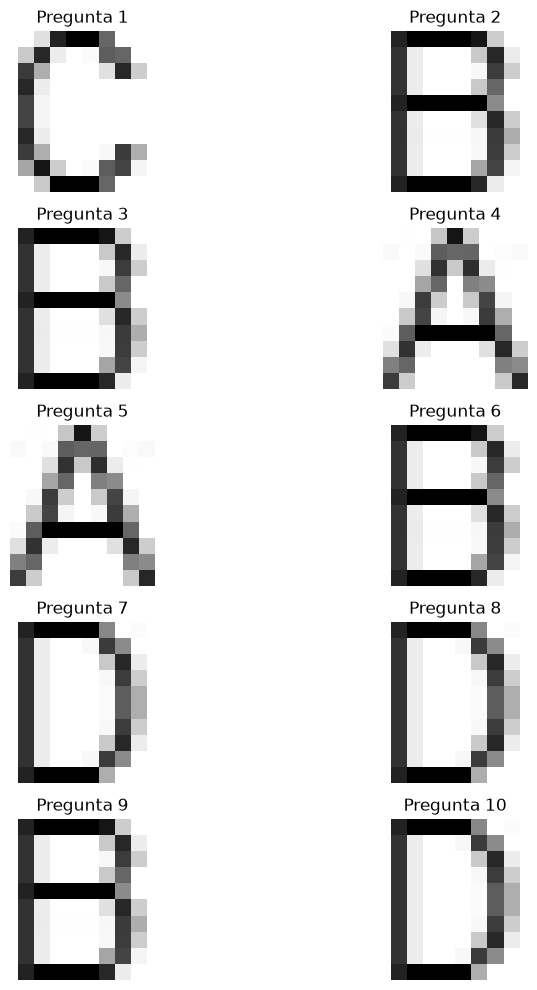

In [29]:
plotear_respuestas(examenes[5]['respuestas'])